<a href="https://colab.research.google.com/github/Utkarsh-sengar3/AI-ML-Learning/blob/main/Unsupervised-Learning/Unsupervised_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# python dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn
from sklearn.cluster import KMeans

In [ ]:
import pandas as pd # Ensure pandas is imported as it's used later in the cell

# Removed requests import and download logic as 'Life Expectancy Data.csv' is directly available.
data=pd.read_csv('/content/Mall_Customers.csv')
print('5 rows of data')
print(data.head())
print('size of the dataset')
print(data.shape)
print('description of data set')
print(data.describe())
print(data.info())
print(data.isnull().sum())

5 rows of data
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
size of the dataset
(200, 5)
description of data set
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000             

In [ ]:
X=data[['Annual Income (k$)','Spending Score (1-100)']]
print(X)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

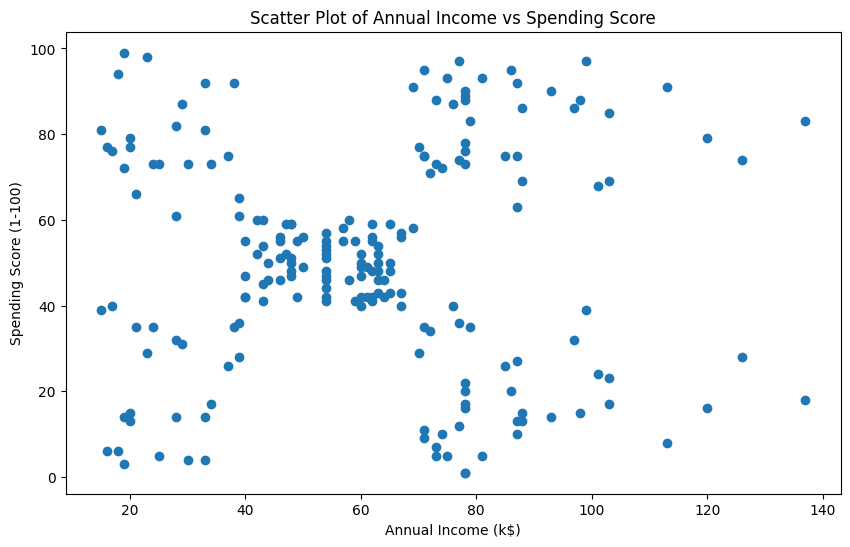

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Scatter Plot of Annual Income vs Spending Score')
plt.show()

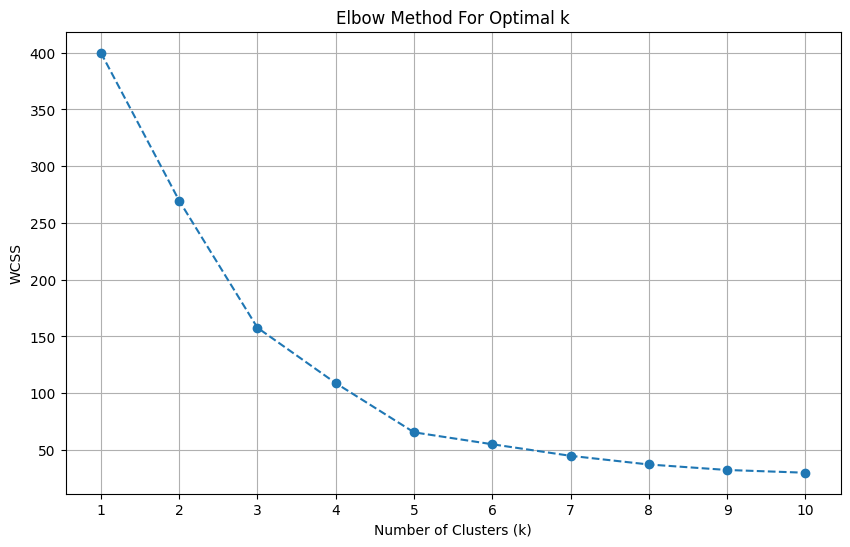

In [ ]:
from sklearn.cluster import KMeans
#kmeans inwrtia??
# Determine optimal number of clusters using the elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


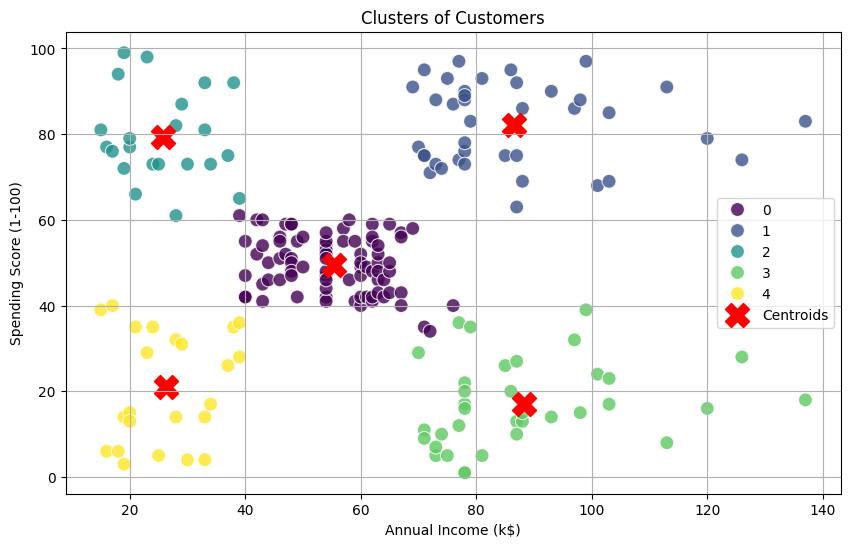

In [ ]:
# Apply K-Means with the optimal number of clusters (k=5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add the cluster labels to the original (non-scaled) DataFrame for easier interpretation
X_original = data[['Annual Income (k$)','Spending Score (1-100)']].copy()
X_original['Cluster'] = y_kmeans

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=X_original,
    palette='viridis',
    s=100,
    alpha=0.8
)

# Plot the cluster centers (optional, but good for understanding)
centers_scaled = kmeans.cluster_centers_
# Inverse transform the scaled centers to the original scale for plotting with original X
centers_original = scaler.inverse_transform(centers_scaled)
plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

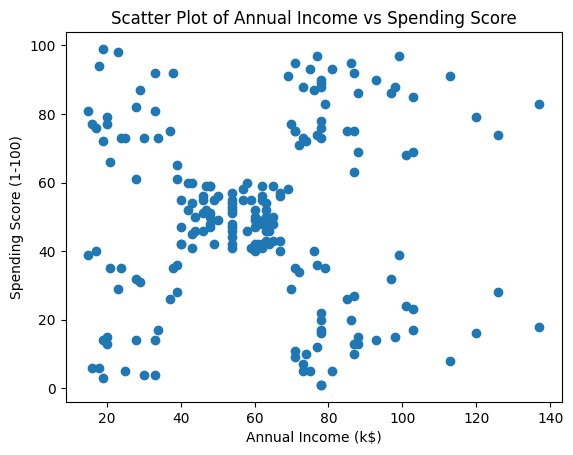

In [ ]:
plt.scatter(X['Annual Income (k$)'],X['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Scatter Plot of Annual Income vs Spending Score')
plt.show()

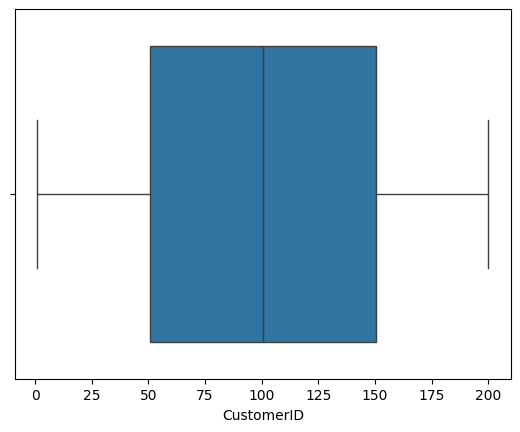

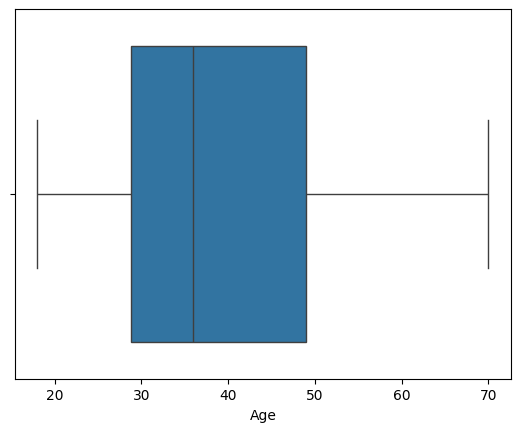

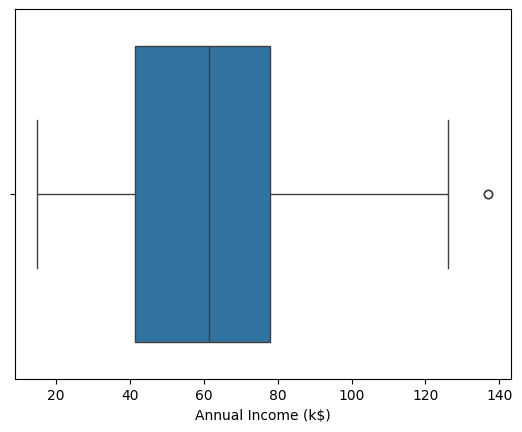

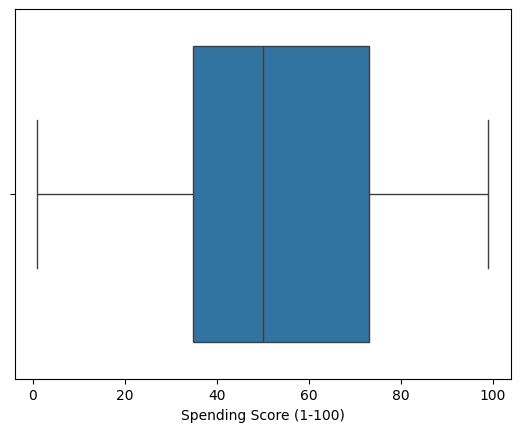

In [ ]:
for i in data.select_dtypes(include='number').columns: # Changed df to data
  sns.boxplot(data=data, x = i) # Changed df to data
  plt.show()

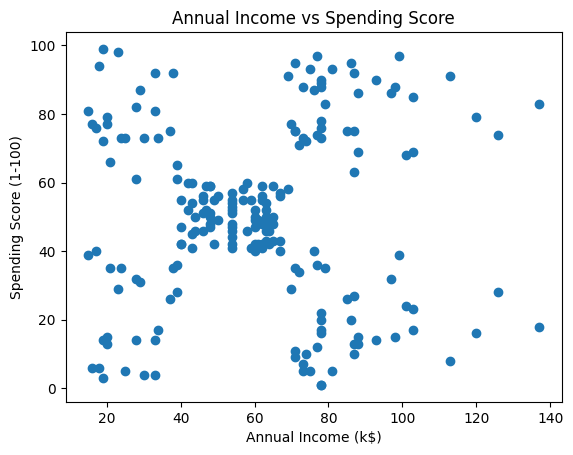

In [ ]:
#scatter plot to check the relationship
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.show()

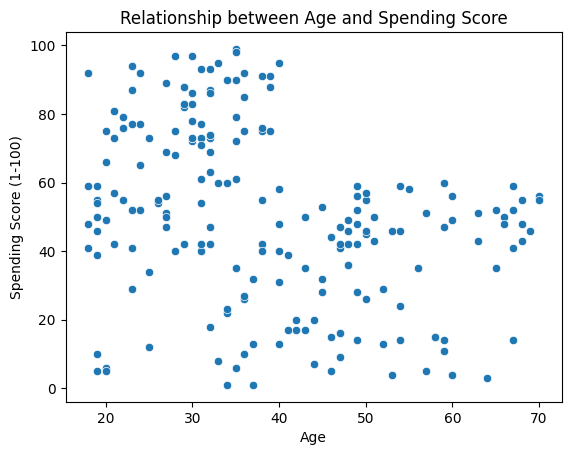

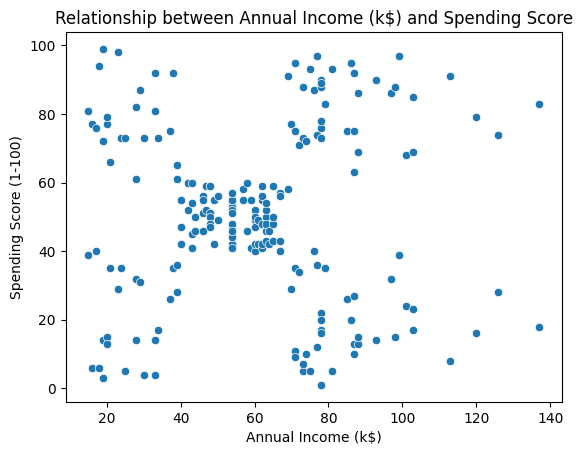

In [ ]:
for col in ['Age', 'Annual Income (k$)']:
    sns.scatterplot(data=data, x=col, y='Spending Score (1-100)')
    plt.title(f'Relationship between {col} and Spending Score')
    plt.xlabel(col)
    plt.ylabel('Spending Score (1-100)')
    plt.show()

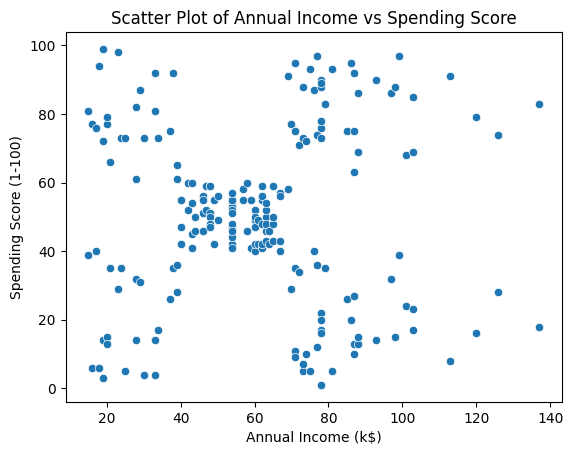

In [ ]:
sns.scatterplot(data=data, x='Annual Income (k$)', y='Spending Score (1-100)')
plt.title('Scatter Plot of Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [ ]:
#corelation
data.select_dtypes(include='number').corr()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


In [ ]:
#missing values
df = pd.read_csv('/content/Mall_Customers.csv')
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
#remove extra spaces from column names
df.columns = df.columns.str.strip()

In [ ]:
#fill missing values with median

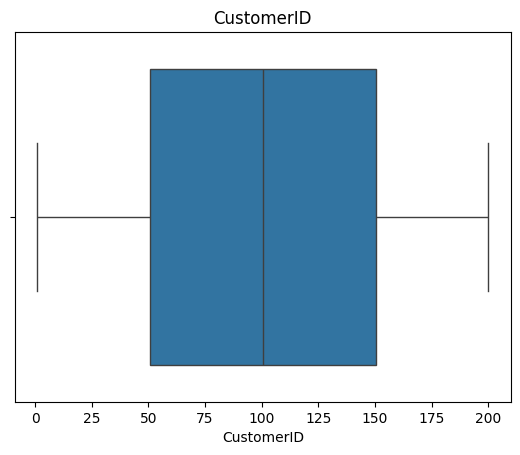

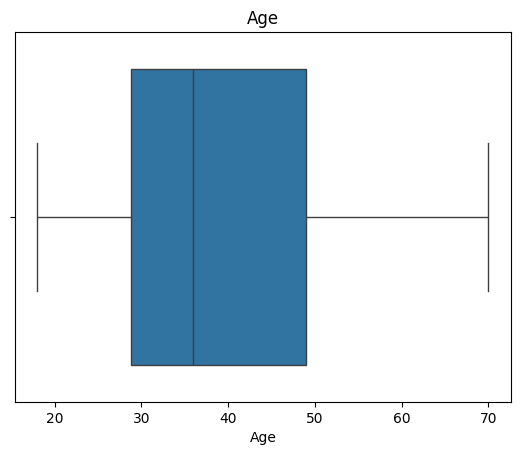

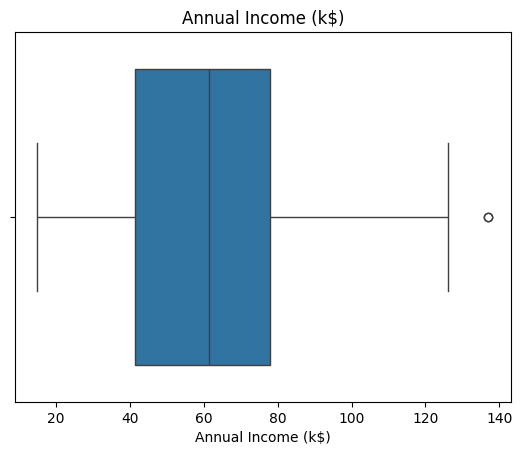

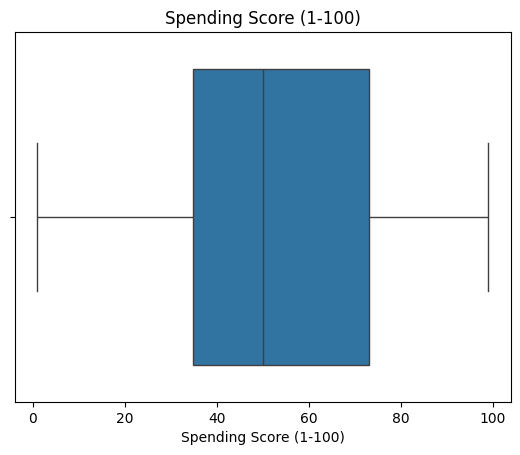

In [ ]:
#outlier
import seaborn as sns
import matplotlib.pyplot as plt
for col in data.select_dtypes(include="number"): # Changed df to data
  sns.boxplot(x=data[col]) # Changed df to data
  plt.title(col) # Fixed typo: titile to title
  plt.show()

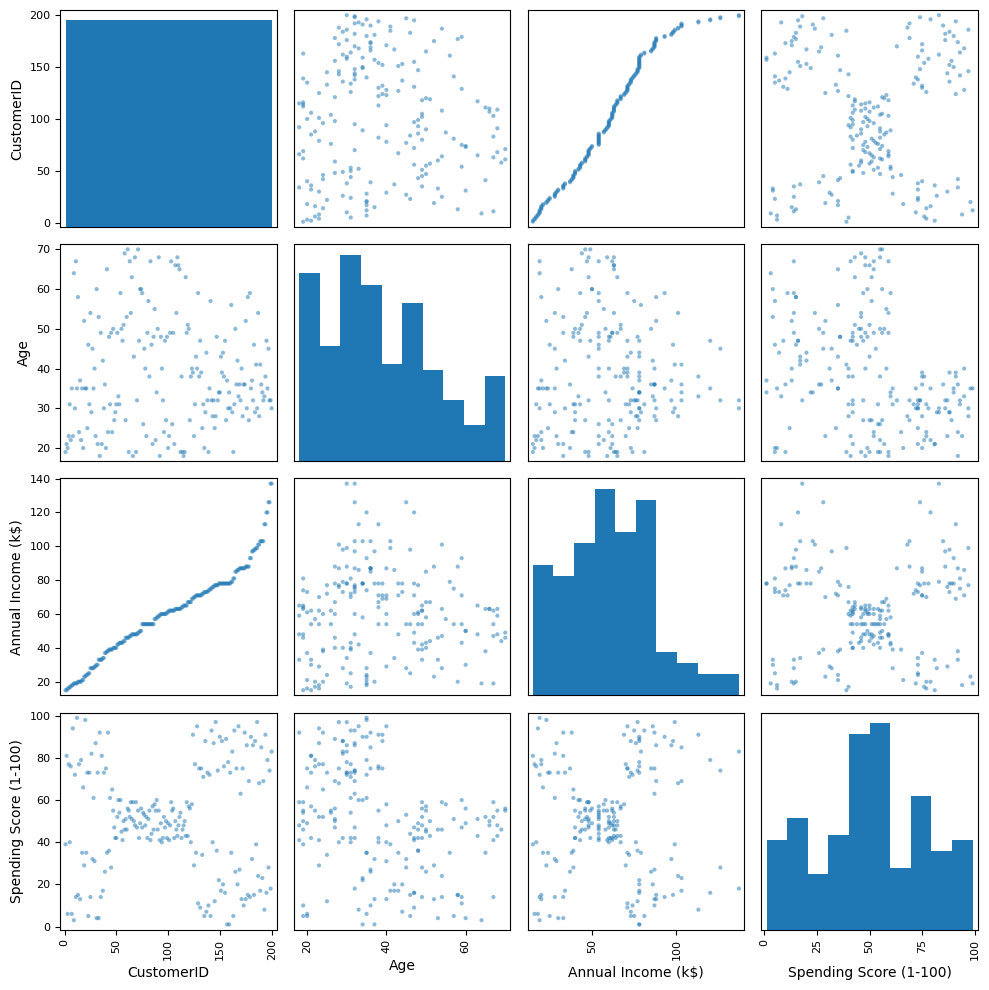

In [ ]:
#from IPython.core.formatters import PlainTextFormatter
import matplotlib.pyplot as plt
numeric_data = df.select_dtypes(include = 'number')
pd.plotting.scatter_matrix(numeric_data, figsize = (10,10))
plt.tight_layout()
plt.show()

In [ ]:
x = df.iloc[:,[3,4]]
x.columns = ["Annual Income","Spending"]
print(X)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


In [ ]:
#columns = ['AnnualscaledIncome','scaledpending']
x_scaled_df= pd.DataFrame(X_scaled, columns=x.columns)
print(x_scaled_df)

     Annual Income  Spending
0        -1.738999 -0.434801
1        -1.738999  1.195704
2        -1.700830 -1.715913
3        -1.700830  1.040418
4        -1.662660 -0.395980
..             ...       ...
195       2.268791  1.118061
196       2.497807 -0.861839
197       2.497807  0.923953
198       2.917671 -1.250054
199       2.917671  1.273347

[200 rows x 2 columns]


In [ ]:
print(x_scaled_df.head())

   Annual Income  Spending
0      -1.738999 -0.434801
1      -1.738999  1.195704
2      -1.700830 -1.715913
3      -1.700830  1.040418
4      -1.662660 -0.395980


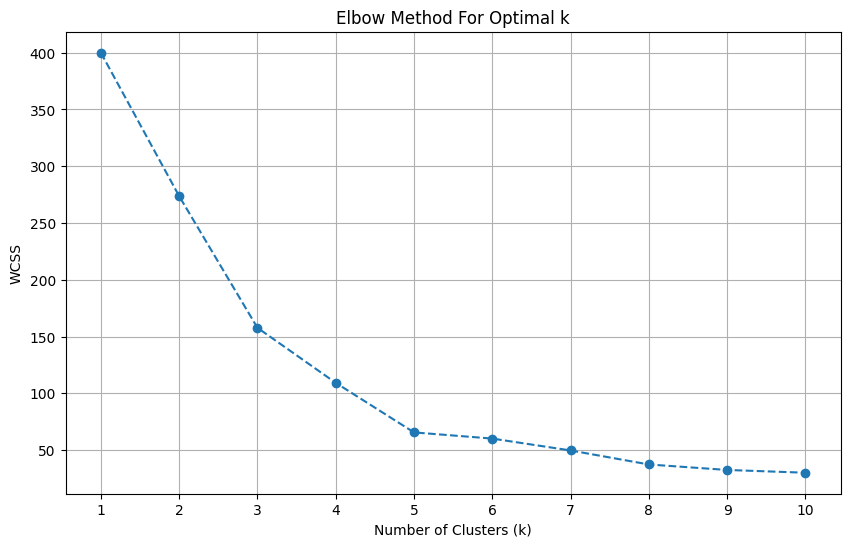

30.05932269404222


In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(x_scaled_df)
  wcss.append(kmeans.inertia_)
plt.figure(figsize=(10,6))
plt.plot(range(1,11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(range(1,11))
plt.grid(True)
plt.show()
inter = kmeans.inertia_
print(inter)

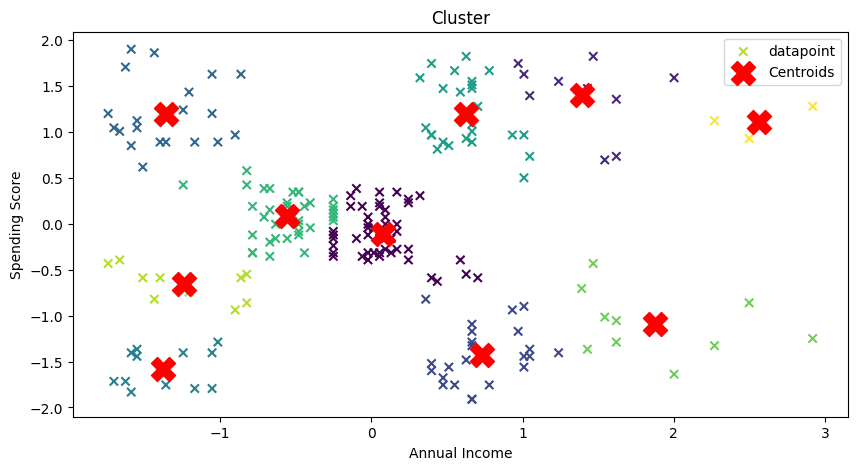

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=kmeans.labels_,marker="x",label="datapoint")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Cluster")
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300, #size of centroid marker
    c='red',
    marker='X',
    label='Centroids'
)
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
plt.figure(figsize=(10,5))


In [ ]:
import pandas as pd

# Create a dictionary with 'age' and 'salary' columns and assign values
data = {
    'age': [25, 30, 35, 40, 45],
    'salary': [50000, 60000, 75000, 90000, 110000]
}

# Optionally, create a DataFrame from the dictionary to display it
df_example = pd.DataFrame(data)
print(df_example)

   age  salary
0   25   50000
1   30   60000
2   35   75000
3   40   90000
4   45  110000


In [ ]:
from sklearn_extra.cluster import KMedoids
kmedoids = KMedoids(n_clusters = 2 , random_state = 42)
model = kmedoids.fit(df)
df['Cluster'] = kmedoids.labels_
print(df)
print("Mediods")
print(df.iloc[kmedoids.medoid_indices_])

   age  salary  Cluster
0   25   50000        0
1   30   60000        0
2   35   75000        0
3   40   90000        1
4   45  110000        1
Mediods
   age  salary  Cluster
1   30   60000        0
3   40   90000        1


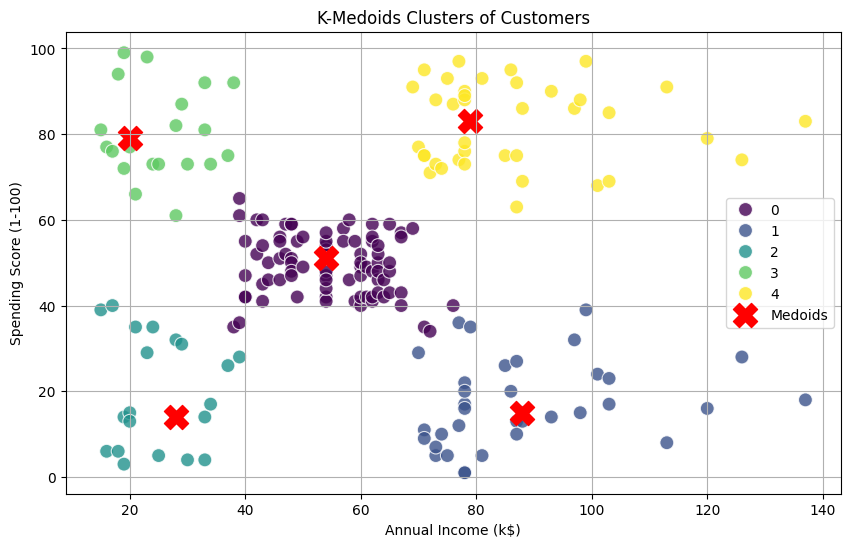

In [ ]:
from sklearn_extra.cluster import KMedoids
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas to use DataFrame
from sklearn.preprocessing import StandardScaler # Required for StandardScaler

# --- Re-establishing data context for Mall Customers analysis ---
# Load the Mall_Customers.csv data (from fIlAhv8w8whe to ensure 'data' is correct)
data = pd.read_csv('/content/Mall_Customers.csv')

# Select 'Annual Income (k$)' and 'Spending Score (1-100)' (from FPye0DdbAIKm)
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the data (from DRYdfEoKbxUT)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# --- End of re-establishing data context ---

# Ensure x_scaled_df is defined from X_scaled and original column names
x_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Apply K-Medoids with the optimal number of clusters (k=5) to the scaled data
kmedoids = KMedoids(n_clusters=5, random_state=42, init='k-medoids++')
y_kmedoids = kmedoids.fit_predict(x_scaled_df)

# Add the cluster labels to the original (non-scaled) DataFrame for easier interpretation
X_kmedoids = X.copy() # X is the original unscaled data for 'Annual Income' and 'Spending Score'
X_kmedoids['Cluster'] = y_kmedoids

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=X_kmedoids,
    palette='viridis',
    s=100,
    alpha=0.8
)

# Plot the medoids (cluster centers) - inverse transform to original scale
medoids_scaled = kmedoids.cluster_centers_
medoids_original = scaler.inverse_transform(medoids_scaled) # 'scaler' was defined earlier for X_scaled

plt.scatter(
    medoids_original[:, 0],
    medoids_original[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Medoids'
)

plt.title('K-Medoids Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

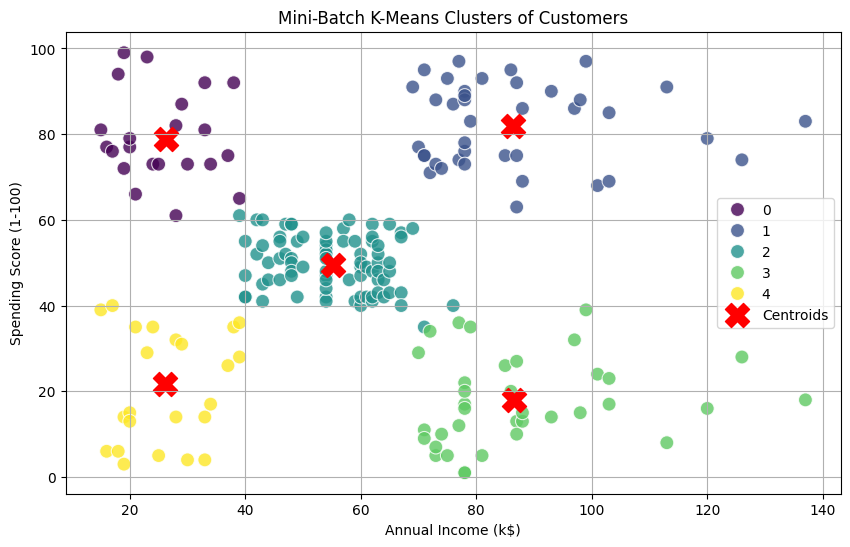

In [ ]:
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# The required variables (X, X_scaled, scaler, x_scaled_df) are already defined in the kernel state.

# Apply Mini-Batch K-Means with the optimal number of clusters (k=5)
# Using n_init='auto' as a modern alternative to explicit n_init values
mbkmeans = MiniBatchKMeans(n_clusters=5, random_state=42, n_init='auto')
y_mbkmeans = mbkmeans.fit_predict(x_scaled_df)

# Add the cluster labels to the original (non-scaled) DataFrame for easier interpretation
X_mbkmeans = X.copy() # X is the original unscaled data for 'Annual Income' and 'Spending Score'
X_mbkmeans['Cluster'] = y_mbkmeans

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=X_mbkmeans,
    palette='viridis',
    s=100,
    alpha=0.8
)

# Plot the cluster centers (centroids) - inverse transform to original scale
centroids_scaled = mbkmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled) # 'scaler' was defined earlier for X_scaled

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('Mini-Batch K-Means Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

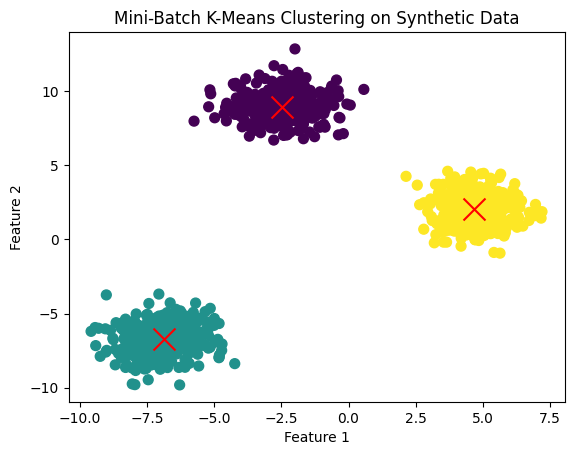

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

#generate synthetic data
x,y = make_blobs(n_samples = 1000, centers = 3, n_features = 2, random_state = 42) # Corrected random_State to random_state

#configure and fit MiniBatchKMeans
mbk_means = MiniBatchKMeans(n_clusters = 3, batch_size = 100, random_state = 42, n_init='auto') # Corrected mnk_means to mbk_means and batch_szie to batch_size, added n_init
mbk_means.fit(x) # Fit on synthetic data 'x' instead of 'X'

#visulize the results
plt.scatter(x[:,0],x[:,1],c=mbk_means.labels_,s=50,cmap='viridis') # Plot synthetic data 'x'
plt.scatter(mbk_means.cluster_centers_[:,0] , mbk_means.cluster_centers_[:,1],s=250,c='red',marker='x')
plt.title('Mini-Batch K-Means Clustering on Synthetic Data')
plt.xlabel('Feature 1') # Updated label for synthetic data
plt.ylabel('Feature 2') # Updated label for synthetic data
plt.show()

cluster centers
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


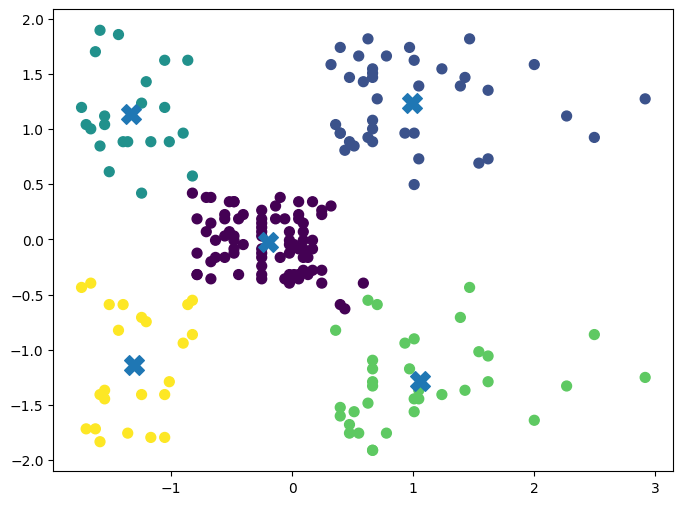

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#load dataset
data = pd.read_csv("Mall_Customers.csv")

#select features
X = data[['Annual Income (k$)','Spending Score (1-100)']]




# 3. Standardize the data (already done in a previous cell, X_scaled is available)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 4. Apply K-Means++
# Import KMeans explicitly if not already imported in this cell (though it is in njIsxvsd5dwS)
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=10, # Explicitly set n_init as per the original code's intent
    random_state=42
)

# 5. Train the model
kmeans.fit(X_scaled) # Corrected 'fir' to 'fit' and 'X_scanled' to 'X_scaled'

# 6. Add cluster labels to dataset
data["cluster"] = kmeans.labels_

#7.Display cluster centers
print("cluster centers")
print(kmeans.cluster_centers_)

#8.Display first few records
print(data.head())

#9.visualize clusters
plt.figure(figsize = (8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmeans.labels_,
    s=50
)

#plot centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker = "X",
    s = 200,
    label = "Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Clusters of Customers")
plt.legend()
plt.show()

#mini batch and kmeans++


In [ ]:
from slearn.cluster import MiniBAtchKMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

#generate synthetic data
X,y - make_blobs(n = samples = 100, centers = 3, n_features = 2, random_state = 42)

#configure and fit MiniBatchKMeans
mbk_means = MiniBatchKMeans(n_clusters = 3, batch_size = 100, random_State = 42)
mbk_means.fir(X)

#Visualize the results
plt.scatter(X[:,0],X[:,1],c=mbk_means.labels_,s=50,cmap='viridis')
plt.scatter(mbk_means.cluster_centers_[:,0],mbk_means.cluster_centers_[:,1],s=200,c='red',marker='X')